# **Análisis Experiencia de cliente**

Objetivos analista d'experiència del client:

- Quina és la puntuació mitjana donada pels usuaris als allotjaments turístics?
- Quin percentatge d'allotjaments tenen una avaluació general més gran de 80 a cada ciutat?

In [353]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [354]:
df = pd.read_csv("../../Data/clean_data_09-03-2026.csv", parse_dates=['insert_date'] )

df

,apartment_id,room_type,price,has_availability,availability_30,availability_60,availability_90,availability_365,review_scores_rating,first_review_date,last_review_date,number_of_reviews,reviews_per_month,city,insert_date,reviews 80+
0,11964,Private room,400.0,True,7,20,40,130,97.0,2010-01-02,2017-09-05,78,0.76,Malaga,2018-07-31,True
1,21853,Private room,170.0,True,0,0,0,162,92.0,2014-10-10,2018-07-15,33,0.52,Madrid,2020-01-10,True
2,32347,Entire home/apt,990.0,True,26,31,31,270,98.0,2011-01-05,2019-07-22,148,1.44,Sevilla,2019-07-29,True
3,35379,Private room,400.0,True,9,23,49,300,94.0,2012-03-13,2020-01-04,292,3.10,Barcelona,2020-01-10,True
4,35801,Private room,900.0,True,0,19,49,312,97.0,2011-07-08,2018-08-08,36,0.39,Girona,2019-02-19,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6610,27237828,Entire home/apt,1500.0,True,22,47,77,78,100.0,2018-08-26,2018-08-26,1,7.60,Girona,2018-08-30,True
6611,27241318,Entire home/apt,3130.0,True,26,37,37,243,100.0,2020-03-13,2020-03-13,1,0.74,Mallorca,2020-04-23,True
6612,27244243,Entire home/apt,990.0,True,24,40,40,40,NaN,NaN,NaN,0,NaN,Girona,2018-08-30,NaN
6613,27244794,Entire home/apt,720.0,True,0,0,0,0,100.0,2018-09-23,2018-09-23,1,0.07,Girona,2019-12-31,True


La columna *reviews_per_month* está recalculada en base a la primera review del alojamiento (*first_review_date*) y la fecha de extracción del registro (*insert_date*). De esta manera, obtenemos los meses reales que existen en los que se han posteado reseñas. Dividimos total de reviews (*number_of_reviews*) con esos meses y obtenemos esta columna recalculada correctamente.

## **Reviews**

## Análisis descriptivos simples

Numero total de reviews

In [355]:
total_reviews = df['number_of_reviews'].sum()
print ("Numero total de reviews a lo largo de los años:", total_reviews )

df['first_review_date'] = pd.to_datetime(df['first_review_date'])
df['last_review_date'] = pd.to_datetime(df['last_review_date'])

# df['first_review_date'].min()
# df['last_review_date'].max()


Numero total de reviews a lo largo de los años: 228314


Evolución numero de reviews

<Axes: title={'center': 'Evolución mensual de Reviews'}, xlabel='last_review_date'>

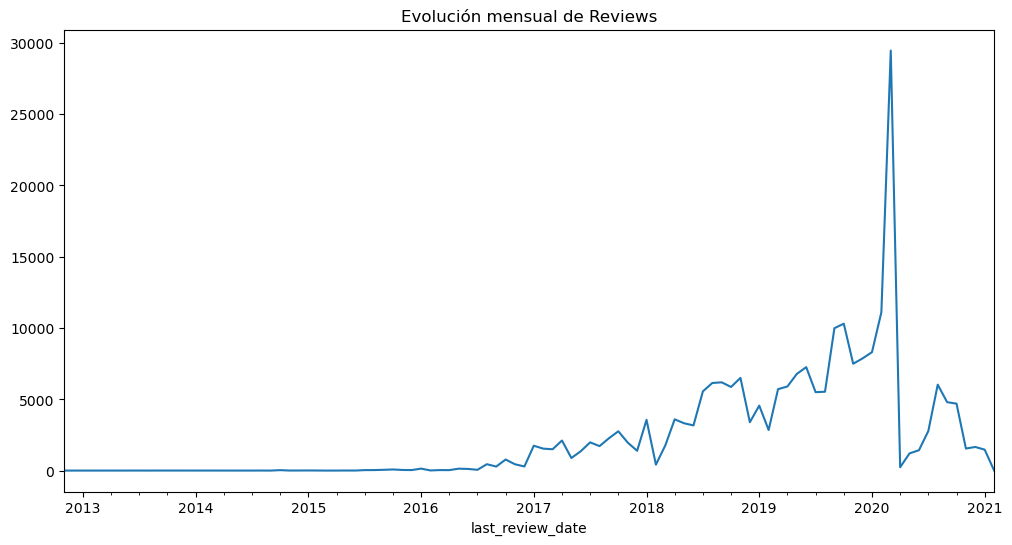

In [356]:
# Agrupar por mes y sumar las reseñas
tendencia = df.groupby(df['last_review_date'].dt.to_period('M'))['number_of_reviews'].sum()

# Visualizar
tendencia.plot(kind='line', figsize=(12, 6), title='Evolución mensual de Reviews')

Tenemos nulos en reviews. Eso es porque hay alojamientos con 0 reseñas.

In [ ]:
df.loc[(df['number_of_reviews'] == 0) & (df['review_scores_rating']).isna()] 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6615 entries, 0 to 6614
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   apartment_id          6615 non-null   int64         
 1   room_type             6615 non-null   object        
 2   price                 6615 non-null   float64       
 3   has_availability      6615 non-null   bool          
 4   availability_30       6615 non-null   int64         
 5   availability_60       6615 non-null   int64         
 6   availability_90       6615 non-null   int64         
 7   availability_365      6615 non-null   int64         
 8   review_scores_rating  5380 non-null   float64       
 9   first_review_date     5451 non-null   datetime64[ns]
 10  last_review_date      5450 non-null   datetime64[ns]
 11  number_of_reviews     6615 non-null   int64         
 12  reviews_per_month     5451 non-null   float64       
 13  city              

In [ ]:
# 1164 alojamientos sin review per month y sin number of review. Un 18% alojamientos no tienen reviews
df.loc[(df['reviews_per_month'].isna()) & (df['review_scores_rating'].isna()) ]

,apartment_id,room_type,price,has_availability,availability_30,availability_60,availability_90,availability_365,review_scores_rating,first_review_date,last_review_date,number_of_reviews,reviews_per_month,city,insert_date,reviews 80+
56,378998,Private room,200.0,False,0,0,0,0,NaN,NaT,NaT,0,NaN,Barcelona,2017-06-05,NaN
96,551339,Entire home/apt,1800.0,True,2,21,51,322,NaN,NaT,NaT,0,NaN,Barcelona,2017-09-12,NaN
130,657565,Entire home/apt,800.0,True,7,16,26,273,NaN,NaT,NaT,0,NaN,Sevilla,2018-07-31,NaN
135,675175,Private room,250.0,True,27,57,87,87,NaN,NaT,NaT,0,NaN,Barcelona,2019-05-14,NaN
159,737169,Entire home/apt,1300.0,False,29,59,89,356,NaN,NaT,NaT,0,NaN,Mallorca,2017-03-15,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6606,27224471,Entire home/apt,540.0,True,30,46,69,179,NaN,NaT,NaT,0,NaN,Girona,2020-02-29,NaN
6607,27224489,Entire home/apt,1030.0,True,14,14,14,213,NaN,NaT,NaT,0,NaN,Girona,2018-12-22,NaN
6608,27224529,Entire home/apt,440.0,True,19,48,58,114,NaN,NaT,NaT,0,NaN,Girona,2019-03-30,NaN
6612,27244243,Entire home/apt,990.0,True,24,40,40,40,NaN,NaT,NaT,0,NaN,Girona,2018-08-30,NaN


Puntuación media, mediana y moda de reviews

In [328]:
avg_rating = df["review_scores_rating"].mean()

print("Puntuación media:", round(avg_rating, 2))

print("Puntuación mediana:", df['review_scores_rating'].median())
print("Puntuación modal:", df['review_scores_rating'].mode()[0])


Puntuación media: 91.99
Puntuación mediana: 94.0
Puntuación modal: 100.0


Para los algoritmos de recomendación de la plataforma, un alojamiento que baja de 4.5 suele ser penalizado y aparece mucho más abajo en las búsquedas. 

Por eso, en análisis de negocio, el 4.5 es la "frontera de supervivencia".

En nuestra escala, eso equivaldría a un 9/10.

Histograma distribución de reviews según precio

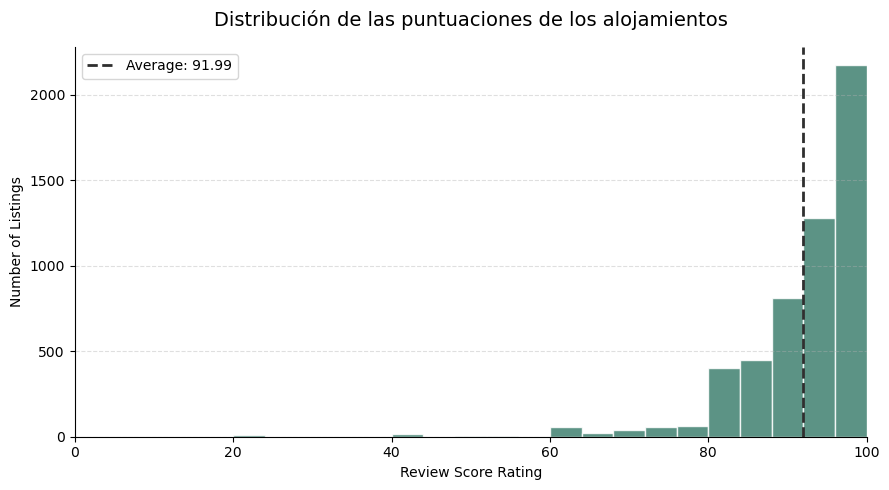

In [329]:
ratings = df["review_scores_rating"].dropna()

# media
avg_rating = ratings.mean()

plt.figure(figsize=(9,5))

# histograma
plt.hist(
    ratings,
    bins=20,
    color="#3f8070",
    edgecolor="white",
    alpha=0.85
)

# línea de media
plt.axvline(
    avg_rating,
    linestyle="--",
    linewidth=2,
    color="#2f2f2f",
    label=f"Average: {avg_rating:.2f}"
)

# límites eje X
plt.xlim(0,100)

# estilo limpio
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.title("Distribución de las puntuaciones de los alojamientos", fontsize=14, pad=15)
plt.xlabel("Review Score Rating")
plt.ylabel("Number of Listings")

plt.legend()

for spine in ["top","right"]:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

<Axes: >

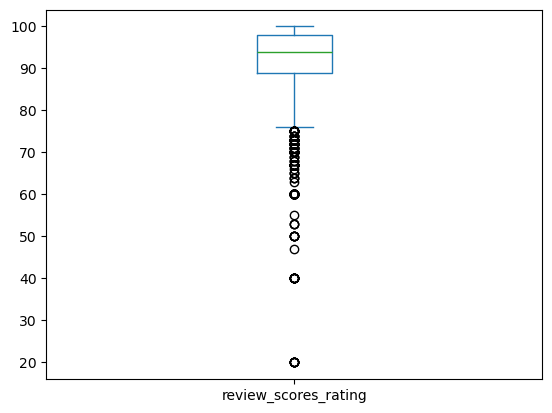

In [368]:
df['review_scores_rating'].plot.box()

Como es una distribución asimétrica, mejor usar la mediana que la media, ya que nos da una aproximación mejor para describir el conjunto.

Puntuación media por ciudad

In [330]:
df.groupby('city')[['review_scores_rating']].mean().sort_values(by='review_scores_rating',ascending=False).round(2)

,review_scores_rating
city,
Sevilla,93.78
Menorca,93.37
Mallorca,93.36
Madrid,92.76
Valencia,92.44
Malaga,92.13
Girona,91.06
Barcelona,90.71


Puntuación mediana por ciudad

In [331]:
df.groupby('city')[['review_scores_rating']].median().sort_values(by='review_scores_rating',ascending=False)

,review_scores_rating
city,
Mallorca,96.0
Madrid,95.0
Menorca,95.0
Sevilla,95.0
Girona,94.0
Valencia,94.0
Barcelona,93.0
Malaga,93.0


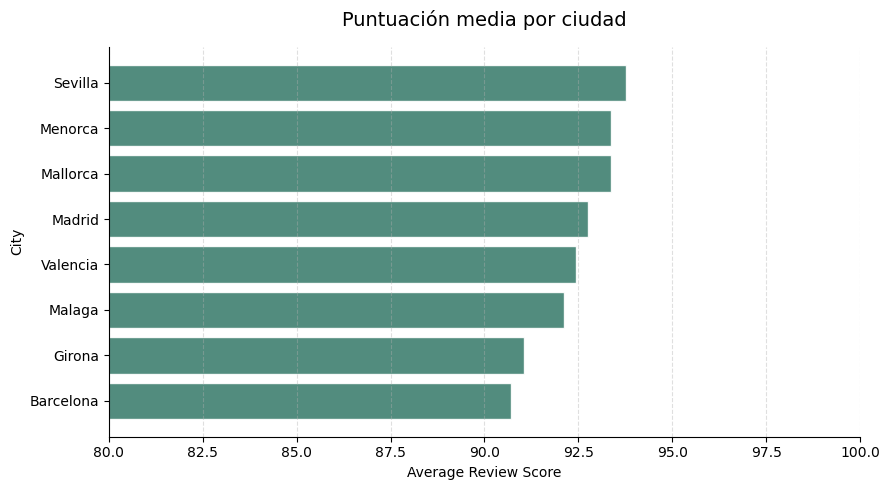

In [332]:
import pandas as pd
import matplotlib.pyplot as plt



# cálculo
avg_rating_city = (
    df.groupby("city")["review_scores_rating"]
      .mean()
      .sort_values(ascending=False)
      .round(2)
      .to_frame(name="avg_rating")
)

plt.figure(figsize=(9,5))

plt.barh(
    avg_rating_city.index,
    avg_rating_city["avg_rating"],
    color="#3f8070",
    edgecolor="white",
    alpha=0.9
)

plt.gca().invert_yaxis()

plt.title("Puntuación media por ciudad", fontsize=14, pad=15)
plt.xlabel("Average Review Score")
plt.ylabel("City")

plt.grid(axis="x", linestyle="--", alpha=0.4)

for spine in ["top","right"]:
    plt.gca().spines[spine].set_visible(False)

plt.xlim(80,100)

plt.tight_layout()
plt.show()

Ciudades con más reviews

<Axes: xlabel='city'>

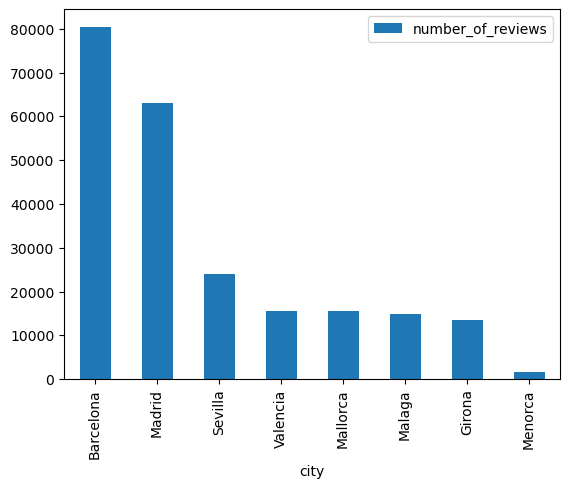

In [376]:
df.groupby('city')[['number_of_reviews']].sum().sort_values(by='number_of_reviews',ascending=False).plot.bar()

Ciudades con más reviews vs ciudades con más alojamientos, porcentajes.

Para comparar si las ciudades más potentes a nivel de alojamientos también son las que más reciben reviews.

<Axes: xlabel='city'>

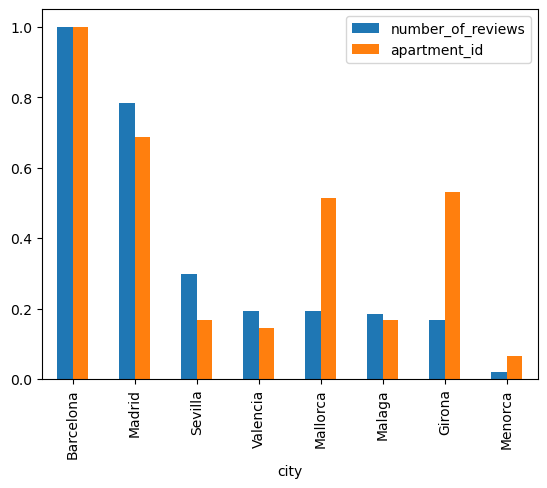

In [401]:
# df.groupby('city')[['number_of_reviews', 'apartment_id']].agg({'number_of_reviews': 'sum', 'apartment_id': 'count'}).plot.bar()

city_stats = df.groupby('city').agg({'number_of_reviews': 'sum','apartment_id': 'count'}).sort_values('number_of_reviews', ascending=False)

city_stats_norm = city_stats / city_stats.max()

city_stats_norm.plot.bar()

Mayor puntuación es porque reciben más reviews? Hay correlación?

C:\Users\Laura\AppData\Local\Temp\ipykernel_10472\3471439076.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  corr_puntuacion_numreviews.total_reviews[i] + 0.1, # Ajuste pequeño en x
C:\Users\Laura\AppData\Local\Temp\ipykernel_10472\3471439076.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  corr_puntuacion_numreviews.puntuacion_media[i] + 0.01, # Ajuste pequeño en y


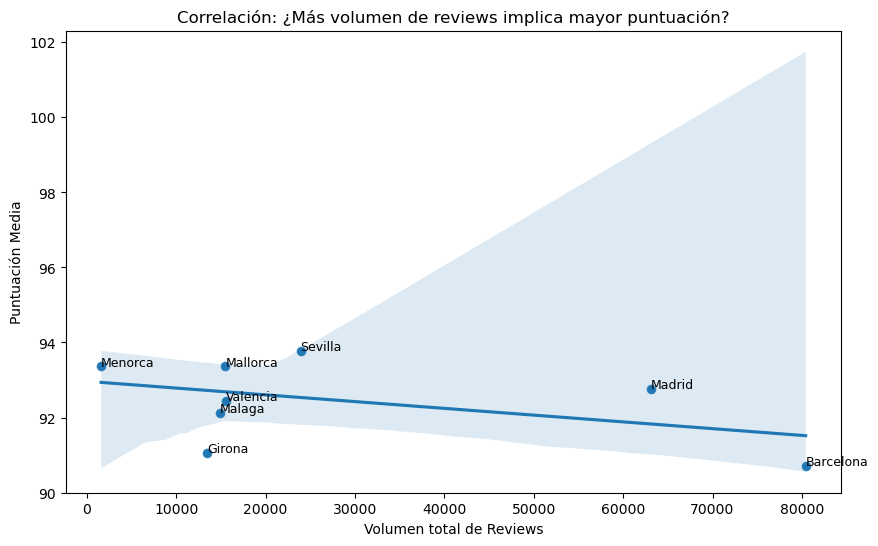

,total_reviews,puntuacion_media
total_reviews,1.000000,-0.451061
puntuacion_media,-0.451061,1.000000


In [414]:
corr_puntuacion_numreviews = pd.DataFrame({
    'total_reviews': df.groupby('city')['number_of_reviews'].sum(),
    'puntuacion_media': df.groupby('city')['review_scores_rating'].mean()
})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=corr_puntuacion_numreviews, x='total_reviews', y='puntuacion_media')

# 2. Iterar sobre los datos para poner las etiquetas
for i, city in enumerate(corr_puntuacion_numreviews.index):
    plt.text(
        corr_puntuacion_numreviews.total_reviews[i] + 0.1, # Ajuste pequeño en x
        corr_puntuacion_numreviews.puntuacion_media[i] + 0.01, # Ajuste pequeño en y
        city, 
        fontsize=9
    )

# Añadir una línea de tendencia (regresión) para ver la correlación clara
sns.regplot(data=corr_puntuacion_numreviews, x='total_reviews', y='puntuacion_media')

plt.title('Correlación: ¿Más volumen de reviews implica mayor puntuación?')
plt.xlabel('Volumen total de Reviews')
plt.ylabel('Puntuación Media')
plt.show()

corr_puntuacion_numreviews[['total_reviews', 'puntuacion_media' ]].corr()

Media de numero de reseñas por alojamiento

In [334]:
#Average del total de reviews
avg_reviews_total = df["number_of_reviews"].mean()

print(f"Avg number of reviews per listing: {avg_reviews_total:.2f}")

Avg number of reviews per listing: 34.51


## KPI

In [ ]:
# Filtro para el cálculo. Filtramos SOLO los 2 valores infinitos para poder calcular reviews_per_month

filas_infinitas = df[np.isinf(df['reviews_per_month'])]


,apartment_id,room_type,price,has_availability,availability_30,availability_60,availability_90,availability_365,review_scores_rating,first_review_date,last_review_date,number_of_reviews,reviews_per_month,city,insert_date,reviews 80+
74,461943,Private room,490.0,False,19,49,79,79,100.0,2017-06-05,2017-06-05,1,inf,Barcelona,2017-06-05,True
6488,26662713,Private room,180.0,True,8,38,54,145,NaN,2018-07-10,2018-07-10,1,inf,Madrid,2018-07-10,NaN


Para reviews_per_month hay que añadir el fillna porque sino solo nos coje los alojamientos que SI tienen reseñas, nosotras evaluamos todo el mercado (tambien los alojamientos sin reseña o nuevos)

In [352]:
# KPI 1 — Average rating
avg_rating = df["review_scores_rating"].mean()

# KPI 2 — Average reviews per month
avg_reviews_month = df["reviews_per_month"].fillna(0).drop(filas_infinitas.index).mean()

print("KPI RESULTS")
print("---------------------")
print(f"Avg rating (all scores): {avg_rating:.2f}")
print(f"Avg reviews per month: {avg_reviews_month:.2f}")

KPI RESULTS
---------------------
Avg rating (all scores): 91.99
Avg reviews per month: 1.21


## Outliers

Vamos a ver a quién pertenecen los outliers. (Estiran la media hacia la baja)

Los que tienen outliers con puntuaciones más bajas coinciden con las 4 ciudades con más alojamientos del dataset.

<Axes: xlabel='city'>

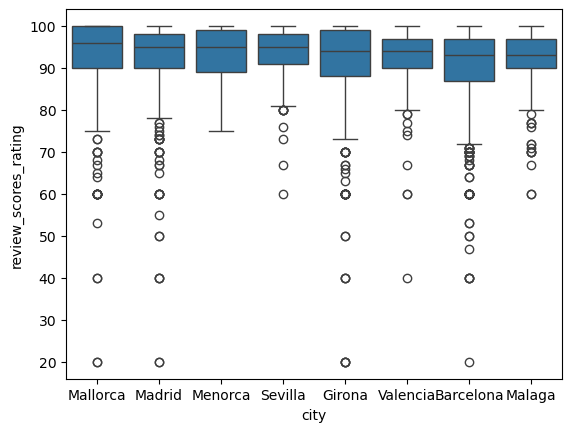

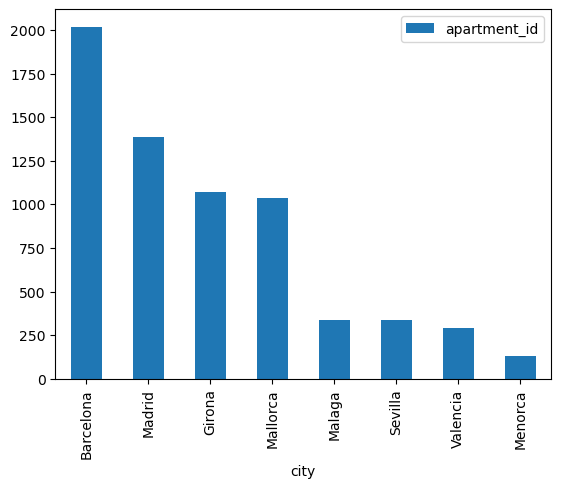

In [337]:
orden_ciudades = df.groupby('city')['review_scores_rating'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='city', y='review_scores_rating', order = orden_ciudades)

df.groupby('city')[['apartment_id']].count().sort_values(by='apartment_id',ascending=False).plot.bar()

Han salido 76 apartamentos que tienen numero de reseñas, pero valores nulos en Reviews (Error?)

En cambio, hay 1251 apartamentos que no tienen reviews todavía (Son nuevos? / No tienen reseña simplemente?)

In [338]:
# Filtramos los apartamentos que tienen alguna reseña, pero que no tienen nota global
anomalias = df[(df['number_of_reviews'] > 0) & (df['review_scores_rating'].isna())]

print(f"Número de casos raros encontrados: {len(anomalias)}")
# anomalias.sort_values(by="number_of_reviews", ascending=False) No tienen muchas reviews

Número de casos raros encontrados: 74


In [339]:
sin_review = df[(df['number_of_reviews'] == 0) & (df['review_scores_rating'].isna())]
sin_review
print(f"Número de apartamentos sin review encontrados: {len(sin_review)}")

Número de apartamentos sin review encontrados: 1161


## Análisis bivariados

Quin percentatge d'allotjaments tenen una avaluació general més gran de 80 a cada ciutat?

In [340]:
# Alojamientos con calificación superior a 8, por ciudad.
rating_superior_8 = df.loc[df['review_scores_rating'] >= 8].groupby('city')[['apartment_id']].count()

# El total de alojamientos por ciudad
total_por_ciudad = df.groupby('city')[['apartment_id']].count()

# Porcentaje de alojamientos con una calificación mayor a 8, según ciudad.
alojamientos_top_ciudad = (rating_superior_8 / total_por_ciudad )* 100

alojamientos_top_ciudad.sort_values('apartment_id', ascending=False)


,apartment_id
city,
Valencia,93.877551
Sevilla,92.330383
Malaga,91.445428
Madrid,85.425685
Menorca,83.582090
Barcelona,83.234127
Mallorca,73.648649
Girona,69.467787


<Axes: xlabel='city'>

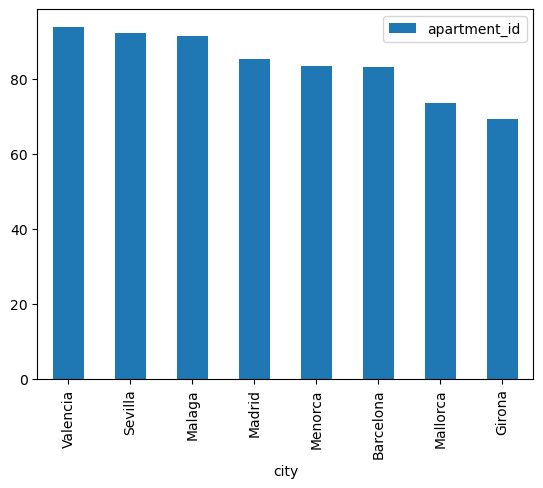

In [341]:
alojamientos_top_ciudad.sort_values('apartment_id', ascending=False).plot.bar()

Curva de Distribución Acumulada

¿Qué porcentaje de mis alojamientos tienen una nota igual o superior a 80?

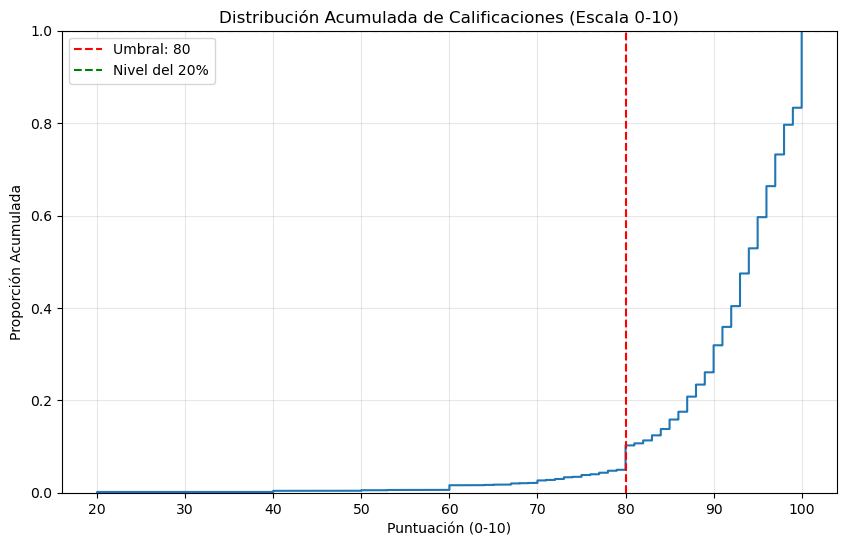

In [342]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df, x='review_scores_rating')

# 3. Líneas de referencia para una lectura rápida
# Por ejemplo: queremos ver qué porcentaje está por encima de un 80
plt.axvline(80, color='red', linestyle='--', label='Umbral: 80')
plt.axhline(1, color='green', linestyle='--', label='Nivel del 20%')

plt.title('Distribución Acumulada de Calificaciones (Escala 0-10)')
plt.xlabel('Puntuación (0-10)')
plt.ylabel('Proporción Acumulada')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Por encima de un rating de 8, el 95% de los alojamientos.

Por encima de un rating de 9, el 74% de los alojamientos.

In [343]:
# % alojamientos por encima del rating 8
total_alojamientos_con_review= df.dropna(subset=['review_scores_rating']) # Cuidado con los nulos, hay que descartar para que porcentaje sea correcto.

total_alojamientos_con_review = total_alojamientos_con_review.shape[0] # Sacamos nº total de alojamientos con review

rating_above_8 = df.loc[df['review_scores_rating'] >= 80][['apartment_id']].count() 
rating_above_9 = df.loc[df['review_scores_rating'] >= 90][['apartment_id']].count() 
per_above_8 = rating_above_8 / total_alojamientos_con_review
per_above_9 = rating_above_9 / total_alojamientos_con_review
print(per_above_8)
print(per_above_9)

apartment_id    0.950372
dtype: float64
apartment_id    0.739405
dtype: float64


## Tarjetas

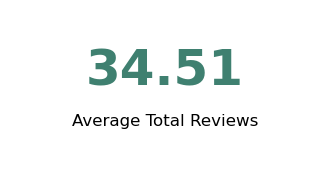

In [344]:
plt.figure(figsize=(4,2))

plt.text(
    0.5, 0.6,
    f"{avg_reviews_total:.2f}",
    ha="center",
    va="center",
    fontsize=36,
    color="#3f8070",
    fontweight="bold"
)

plt.text(
    0.5, 0.25,
    "Average Total Reviews",
    ha="center",
    fontsize=12
)

plt.axis("off")
plt.show()

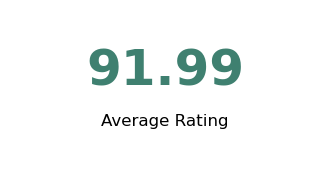

In [345]:
plt.figure(figsize=(4,2))

plt.text(
    0.5, 0.6,
    f"{avg_rating:.2f}",
    ha="center",
    va="center",
    fontsize=36,
    color="#3f8070",
    fontweight="bold"
)

plt.text(
    0.5, 0.25,
    "Average Rating",
    ha="center",
    fontsize=12
)

plt.axis("off")
plt.show()

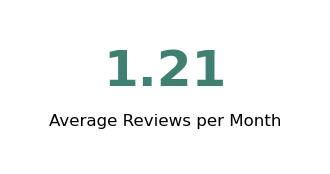

In [346]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,2))

plt.text(
    0.5, 0.6,
    f"{avg_reviews_month:.2f}",
    ha="center",
    va="center",
    fontsize=36,
    color="#3f8070",
    fontweight="bold"
)

plt.text(
    0.5, 0.25,
    "Average Reviews per Month",
    ha="center",
    fontsize=12
)

plt.axis("off")
plt.show()